In [1]:
import torch
import torch.nn.functional as f
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
words = open('C:/Users/Acer/OneDrive/Desktop/YZ50/Week_3/names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [4]:
block_size = 3

def build_dataset(words):
    
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    
    return X,Y


In [5]:
import random

random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [6]:
def cmp(s,dt,t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [7]:
# MLP revised 

n_embd = 10 # number of direction of character embeding
n_hidden  = 64

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd), generator=g) # embeding matrix (27,10)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5 # (270,200)
b1 = torch.randn(n_hidden, generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1 # (200,27)
b2 = torch.randn(vocab_size,generator=g) * 0.1

bngain = torch.ones((1,n_hidden)) * 0.1 + 1.0
bnbias = torch.zeros((1,n_hidden)) * 0.1

parameters = [C,W1,b1,W2,b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters)) # number of parameters
for p in parameters:
    p.requires_grad = True

4137


In [8]:
batch_size = 32
n = batch_size
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]

In [17]:
# Forward Pass for single batch
emb = C[Xb]
embcat = emb.view(emb.shape[0],-1)
# Linear Layer
hprebn = embcat @ W1 + b1
embcat.shape

torch.Size([32, 30])

std: 0.9566003680229187, mean: 0.017336087301373482


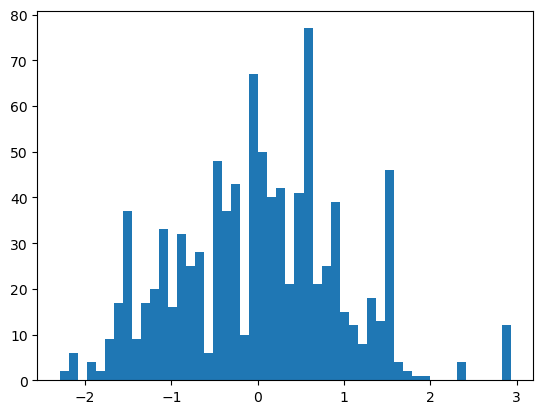

In [26]:
plt.hist(embcat.view(-1).tolist(),50);
print(f'std: {embcat.std().item()}, mean: {embcat.mean()}')

std: 0.3051886260509491, mean: 0.014456117525696754


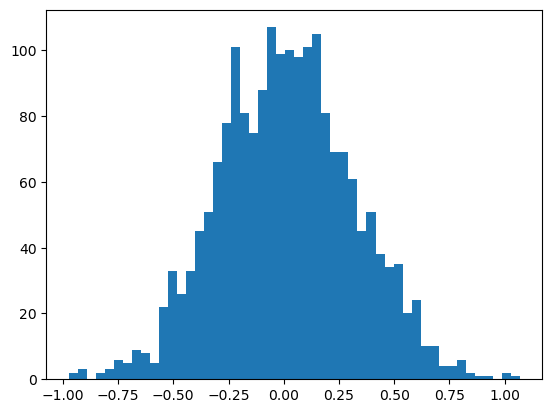

In [27]:
plt.hist(W1.view(-1).tolist(),50);
print(f'std: {W1.std().item()}, mean: {W1.mean()}')

std: 1.6645114421844482, mean: 0.03572453185915947


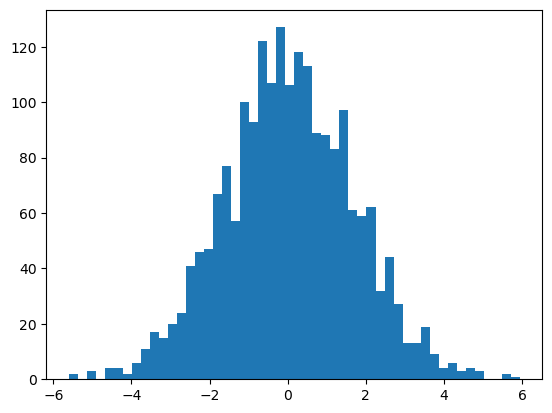

In [29]:
plt.hist(hprebn.view(-1).tolist(),50);
print(f'std: {hprebn.std().item()}, mean: {hprebn.mean()}')

In [ ]:
# Batch Normalization
bnmeani = 1/n*hprebn.sum(0,keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0,keepdim=True)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias